# Clinical Clustering Analysis

In [1]:
# Install required packages
!pip install -q scikit-learn scipy pandas matplotlib seaborn umap-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score,
    silhouette_samples
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from scipy.stats import kruskal, mannwhitneyu
import umap

In [18]:
# Load dataset
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1] / "1" / "Features"
PATIENT_PROFILES_NAME = "patient_profiles.csv"

df = pd.read_csv(FEATURE_PATH / PATIENT_PROFILES_NAME)

print(f"Dataset loaded: {df.shape[0]} patients, {df.shape[1]} features")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nFeature columns:\n{df.columns.tolist()}")

Dataset loaded: 4278 patients, 48 features
Missing values: 0

Feature columns:
['temperature', 'cad_severity_last_missing', 'gender_missing', 'testing_intensity', 'procedure_complexity', 'heart_failure_severity_score_missing', 'cad_severity_last', 'disease_burden_score', 'cardiac_complexity', 'oxygen_saturation', 'metabolic_complexity', 'total_engagement_days', 'age', 'bp_systolic', 'heart_rate', 'k_min', 'high_risk_patient', 'cardiac_remodeling_score', 'admission_count', 'total_procedures', 'readmission_count', 'gender', 'k_n', 'cad_severity_score_missing', 'age_missing', 'ct_complications_score', 'unique_procedures', 'n_invalid', 'hf_severity_last', 'creat_deterioration', 'hf_severity_first', 'hf_severity_first_missing', 'hf_severity_last_missing', 'ecg_abnormality_score', 'k_max', 'hemodynamic_instability_episodes', 'cad_severity_first_missing', 'complex_patient', 'creat_max', 'cad_severity_first', 'renal_function_category', 'infection_severity_score_missing', 'exam_abnormality_scor

## Feature Organization

### Feature Groups

In [19]:
# Define feature groups for clinical interpretation
feature_groups = {
    "Demographics": [
        "age",
        "gender"
    ],
    
    "Vital Signs": [
        "temperature",
        "heart_rate",
        "respiratory_rate",
        "oxygen_saturation",
        "bp_systolic",
    ],
    
    "Lab Values - Electrolytes": [
        "k_min",
        "k_max",
    ],
    
    "Lab Values - Metabolic & Renal": [
        "metabolic_dysregulation",
        "renal_function_category",
    ],
    
    "Clinical Severity Scores": [
        "disease_burden_score",
    ],
    
    "Healthcare Utilization": [
        "total_procedures",
        "procedure_complexity",
        "total_tests",
        "testing_intensity",
    ],
    
    "Risk Indicators": [
        "high_risk_patient",
        "complex_patient",
    ],
    
    "Missingness Indicators": [
        "gender_missing",
        "cad_severity_score_missing",
        "ct_complications_score_missing",
        "infection_severity_score_missing",
    ],
}

# Flatten feature groups for clustering
all_features = []
for group, features in feature_groups.items():
    all_features.extend(features)

print("Feature Groups Summary:")
print("=" * 60)
for group, features in feature_groups.items():
    print(f"{group:40s}: {len(features):2d} features")
print("=" * 60)
print(f"{'Total':40s}: {len(all_features):2d} features")

Feature Groups Summary:
Demographics                            :  2 features
Vital Signs                             :  5 features
Lab Values - Electrolytes               :  2 features
Lab Values - Metabolic & Renal          :  2 features
Clinical Severity Scores                :  1 features
Healthcare Utilization                  :  4 features
Risk Indicators                         :  2 features
Missingness Indicators                  :  4 features
Total                                   : 22 features


In [20]:
# Validate that all features exist in dataframe
missing_features = [f for f in all_features if f not in df.columns]
if missing_features:
    print(f"Missing features: {missing_features}")
else:
    print("All features validated")

# Select features for clustering
features_for_clustering = df.copy()
print(f"\nClustering dataset: {features_for_clustering.shape}")

All features validated

Clustering dataset: (4278, 48)


In [7]:
# Summary statistics by feature group
for group, features in feature_groups.items():
    available_features = [f for f in features if f in df.columns]
    if available_features:
        print(f"\n{group}")
        print("-" * 80)
        display(df[available_features].describe().T)


Demographics
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
age,4761.0,69.774720,9.192112,18.0,65.030621,70.466271,75.268533,95.0
gender,4761.0,0.723377,0.447375,0.0,0.000000,1.000000,1.000000,1.0



Vital Signs
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
temperature,4761.0,2.618679,0.225627,0.000000,2.609703,2.609703,2.609703,4.213931
heart_rate,4761.0,4.348024,0.159861,3.135494,4.343805,4.343805,4.343805,5.303305
respiratory_rate,4761.0,1.165383,0.011460,1.059632,1.164313,1.164313,1.164313,1.254851
oxygen_saturation,4761.0,1.267116,0.646530,0.000000,1.098612,1.386294,1.791759,3.367296
bp_systolic,4761.0,129.108801,15.567417,74.000000,128.000000,128.000000,128.000000,259.000000



Lab Values - Electrolytes
--------------------------------------------------------------------------------


...

,count,mean,std,min,25%,50%,75%,max
total_procedures,4761.0,1.938990,0.575604,1.000000,1.414214,2.000000,2.236068,3.464102
procedure_complexity,4761.0,1.562360,0.497422,0.755929,1.309307,1.414214,1.732051,2.828427
total_tests,4761.0,11.807561,4.500829,1.000000,8.426150,10.862780,14.764823,20.940392
testing_intensity,4761.0,5.588294,0.813488,1.000000,5.066228,5.499216,6.016644,8.130191



Risk Indicators
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
high_risk_patient,4761.0,0.722117,0.803009,0.0,0.0,1.0,1.0,3.0
complex_patient,4761.0,0.721277,0.772578,0.0,0.0,1.0,1.0,3.0



Missingness Indicators
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
gender_missing,4761.0,0.721487,0.448314,0.0,0.0,1.0,1.0,1.0
cad_severity_score_missing,4761.0,0.491283,0.499977,0.0,0.0,0.0,1.0,1.0
ct_complications_score_missing,4761.0,0.659105,0.474060,0.0,0.0,1.0,1.0,1.0
infection_severity_score_missing,4761.0,0.538332,0.498581,0.0,0.0,1.0,1.0,1.0


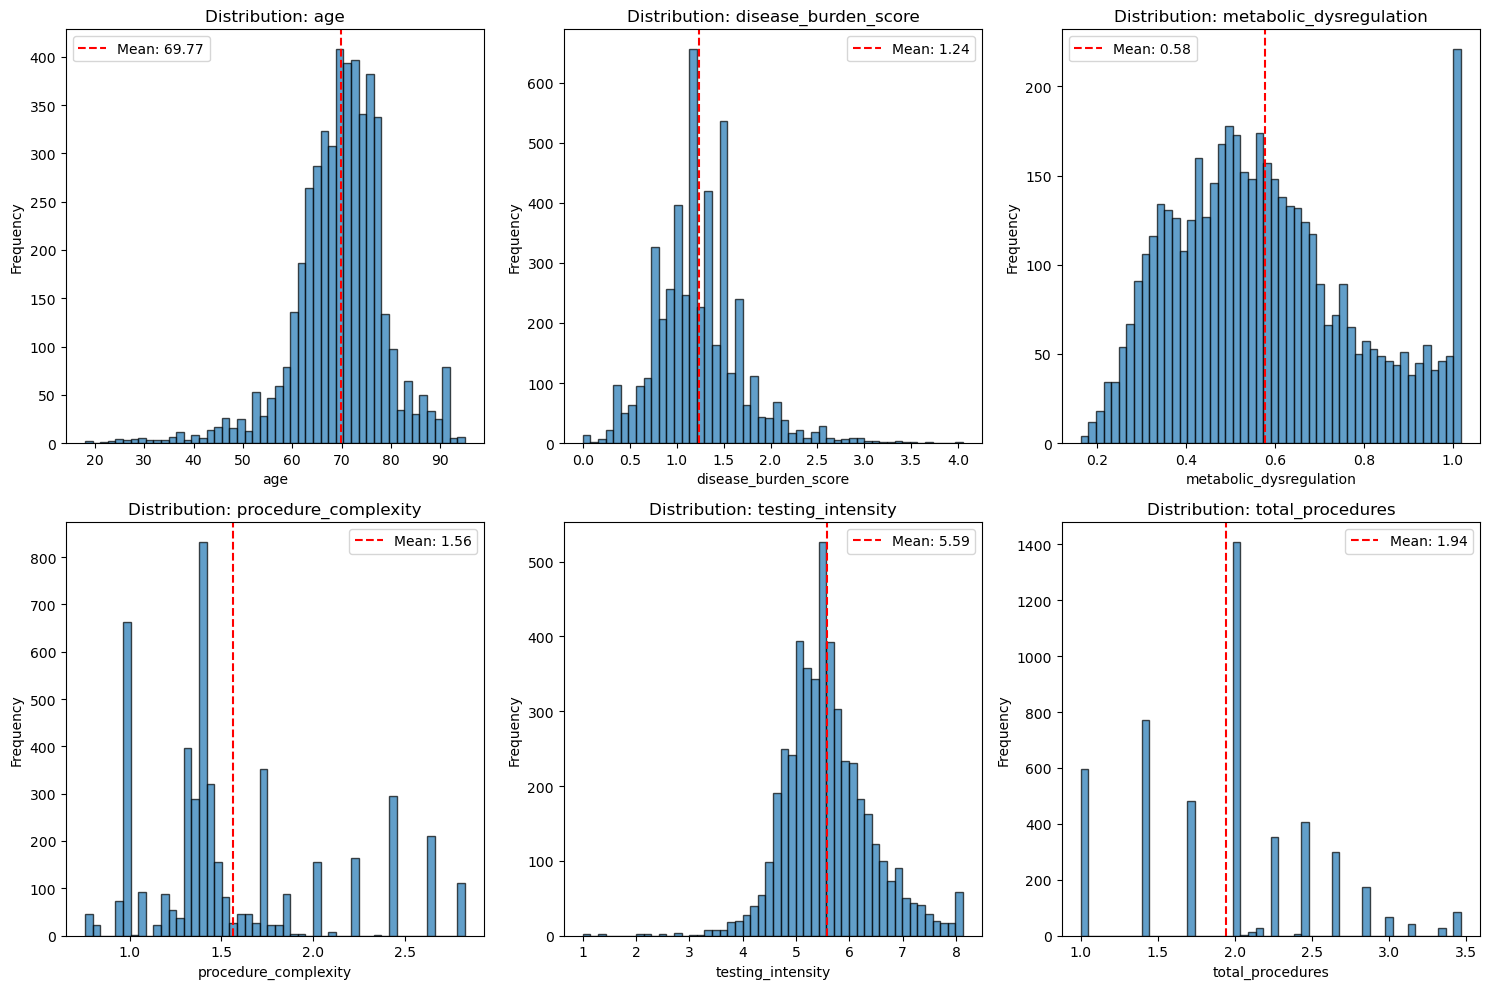

In [8]:
# Distribution plots for key continuous features
continuous_features = [
    'age', 'disease_burden_score', 'metabolic_dysregulation',
    'procedure_complexity', 'testing_intensity', 'total_procedures'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(continuous_features):
    if feature in df.columns:
        axes[idx].hist(df[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution: {feature}')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')
        axes[idx].axvline(df[feature].mean(), color='red', linestyle='--', 
                         label=f'Mean: {df[feature].mean():.2f}')
        axes[idx].legend()

plt.tight_layout()
plt.show()

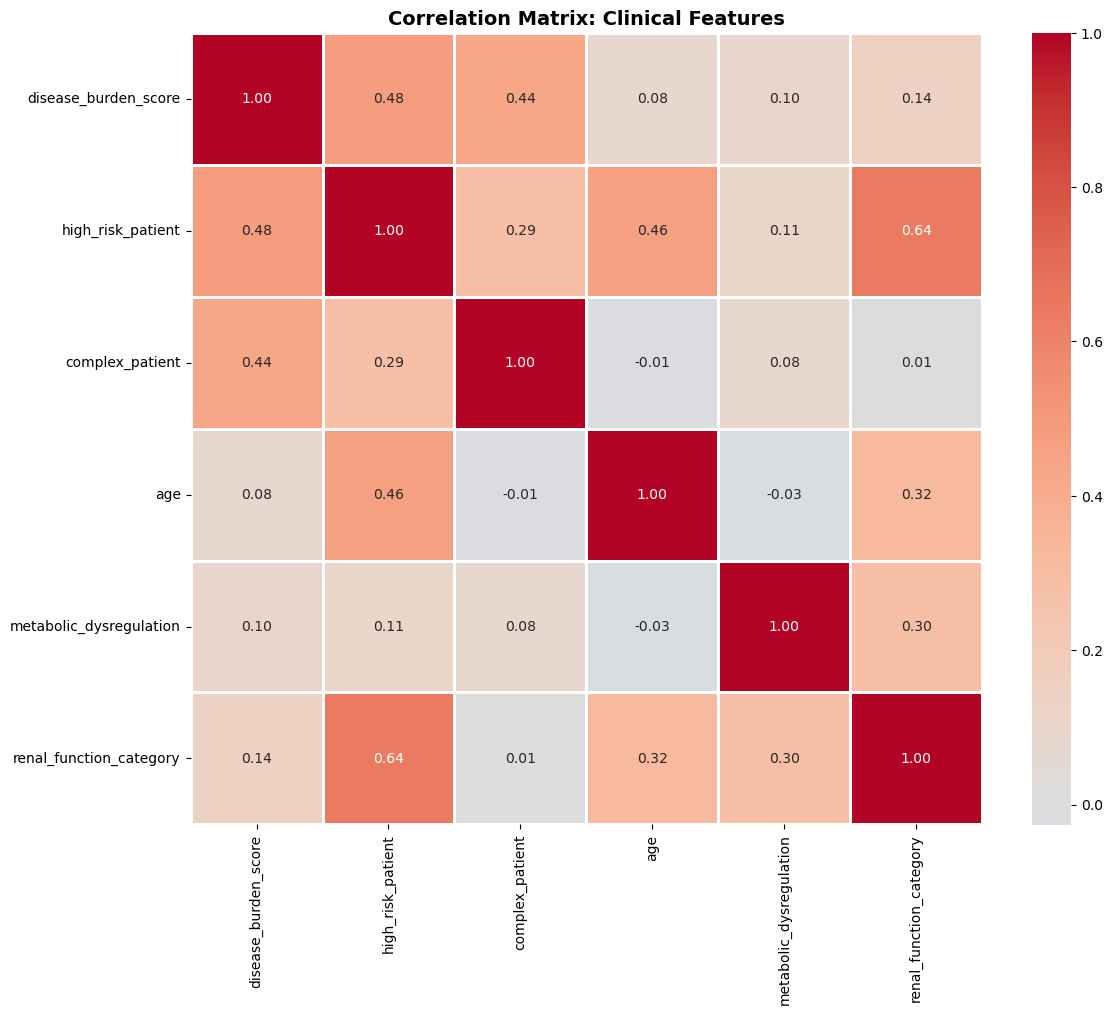

In [9]:
# Correlation matrix for clinical features
clinical_features = (
    feature_groups['Clinical Severity Scores'] + 
    feature_groups['Risk Indicators'] +
    ['age', 'metabolic_dysregulation', 'renal_function_category']
)

available_clinical = [f for f in clinical_features if f in df.columns]
correlation_matrix = df[available_clinical].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix: Clinical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Preprocessing for Clustering

In [21]:
# Separate binary and continuous features for appropriate scaling
from sklearn.compose import ColumnTransformer

binary_cols = []
continuous_cols = []

for col in features_for_clustering.columns:
    unique_vals = features_for_clustering[col].nunique()
    if unique_vals <= 2:
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"Binary features: {len(binary_cols)}")
print(binary_cols)
print(f"\nContinuous features: {len(continuous_cols)}")
print(continuous_cols)

Binary features: 12
['cad_severity_last_missing', 'gender_missing', 'heart_failure_severity_score_missing', 'gender', 'cad_severity_score_missing', 'age_missing', 'creat_deterioration', 'hf_severity_first_missing', 'hf_severity_last_missing', 'cad_severity_first_missing', 'infection_severity_score_missing', 'ct_complications_score_missing']

Continuous features: 36
['temperature', 'testing_intensity', 'procedure_complexity', 'cad_severity_last', 'disease_burden_score', 'cardiac_complexity', 'oxygen_saturation', 'metabolic_complexity', 'total_engagement_days', 'age', 'bp_systolic', 'heart_rate', 'k_min', 'high_risk_patient', 'cardiac_remodeling_score', 'admission_count', 'total_procedures', 'readmission_count', 'k_n', 'ct_complications_score', 'unique_procedures', 'n_invalid', 'hf_severity_last', 'hf_severity_first', 'ecg_abnormality_score', 'k_max', 'hemodynamic_instability_episodes', 'complex_patient', 'creat_max', 'cad_severity_first', 'renal_function_category', 'exam_abnormality_sco

In [22]:
# Create preprocessing pipeline
# Binary: StandardScaler (to normalize 0/1 to similar scale as continuous)
# Continuous: RobustScaler (less sensitive to outliers)
preprocessor = ColumnTransformer(
    transformers=[
        ('binary', StandardScaler(), binary_cols),
        ('continuous', RobustScaler(), continuous_cols)
    ]
)

X_scaled = preprocessor.fit_transform(features_for_clustering)
X_scaled_df = pd.DataFrame(
    X_scaled, 
    columns=binary_cols + continuous_cols,
    index=features_for_clustering.index
)

print("\n✅ Data scaled successfully")
print(f"Scaled data shape: {X_scaled_df.shape}")
print(f"\nScaled data statistics:")
print(f"Mean (should be ~0 for continuous): {X_scaled[:, len(binary_cols):].mean(axis=0).mean():.4f}")
print(f"Std (should be ~1): {X_scaled.std(axis=0).mean():.4f}")


✅ Data scaled successfully
Scaled data shape: (4278, 48)

Scaled data statistics:
Mean (should be ~0 for continuous): 0.0493
Std (should be ~1): 1.0181


## Dimensionality Reduction for Visualization (PCA and UMAP)

PCA Variance Explained:
  PC1: 89.93%
  PC2: 1.66%
  Total: 91.59%


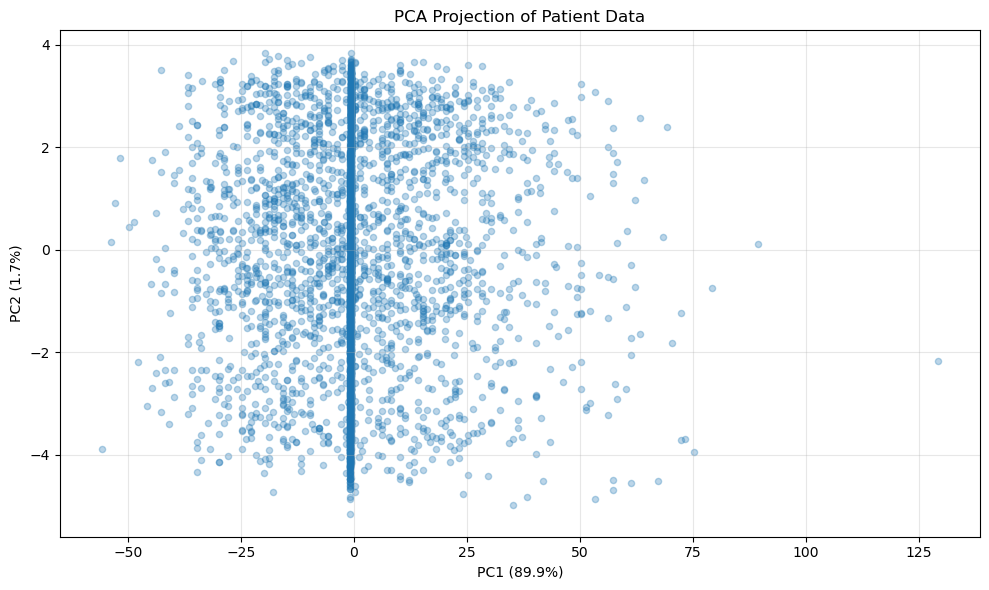

In [23]:
# PCA for linear dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA Variance Explained:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Visualize PCA
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Projection of Patient Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


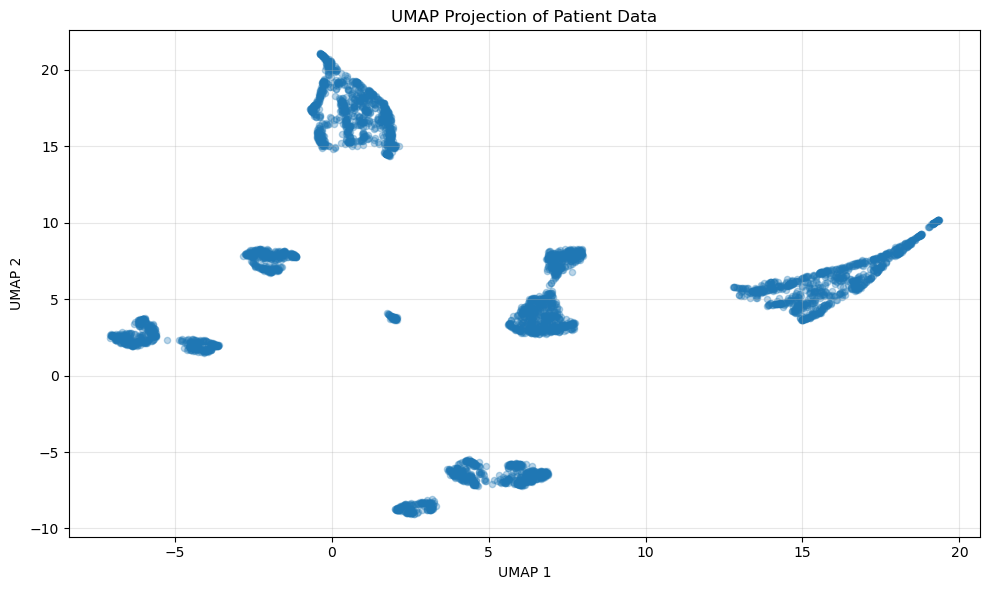

In [24]:
# UMAP for non-linear dimensionality reduction
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,
    metric='euclidean'
)

X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.3, s=20)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Projection of Patient Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Optimal Number of Clusters

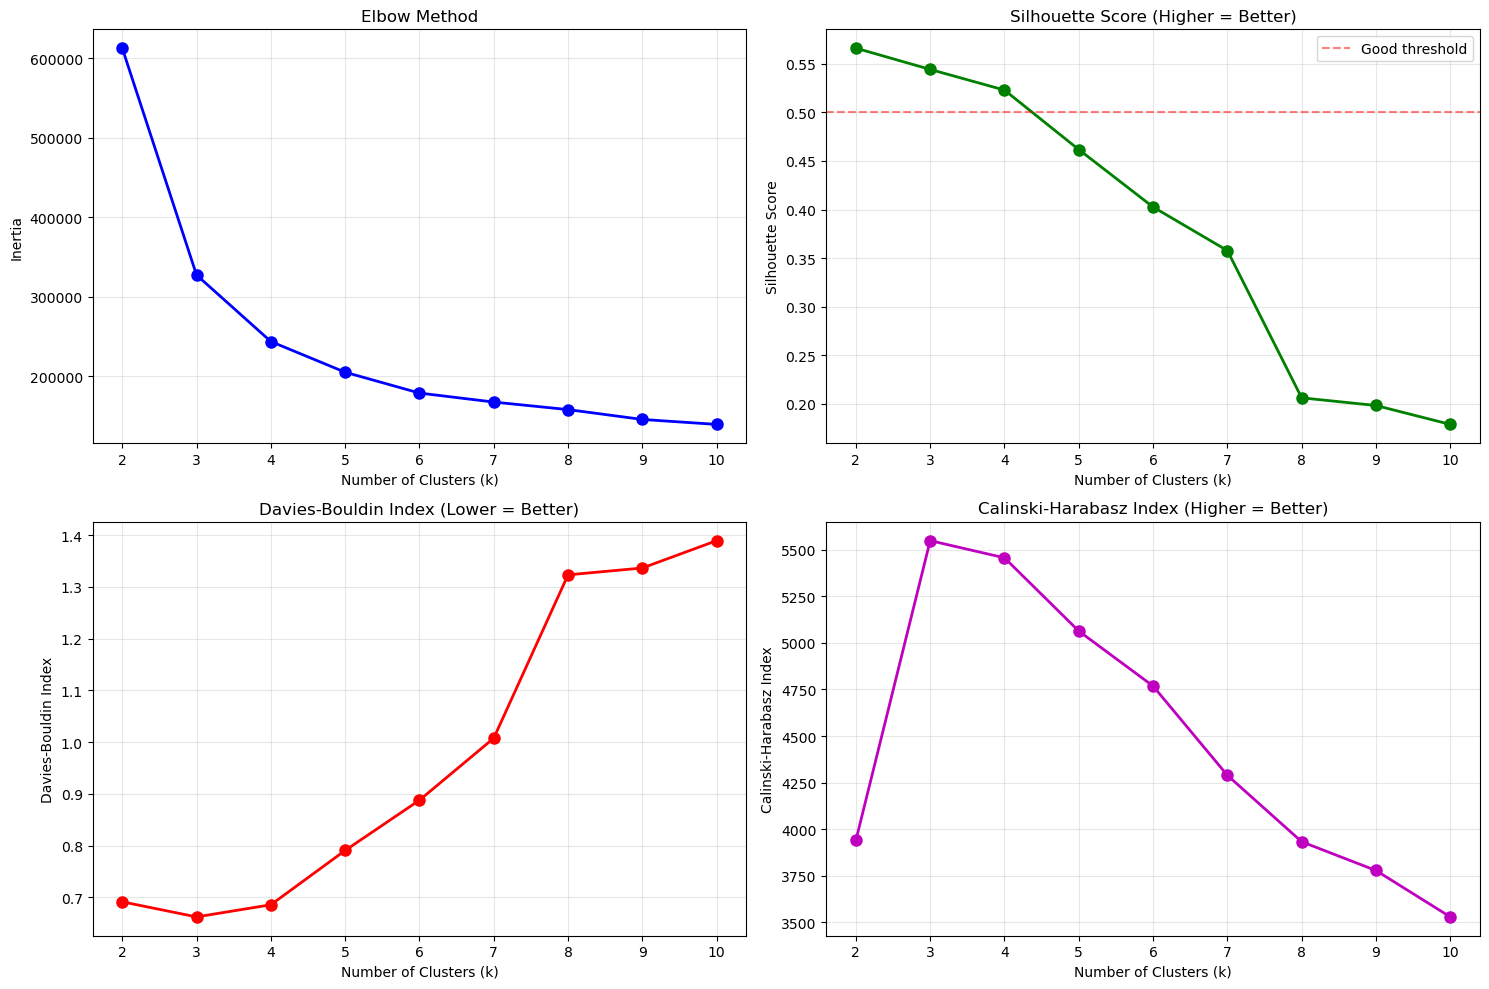

In [26]:
# Plot clustering metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow plot
axes[0, 0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette score (higher is better)
axes[0, 1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score (Higher = Better)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Good threshold')
axes[0, 1].legend()

# Davies-Bouldin index (lower is better)
axes[1, 0].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Davies-Bouldin Index')
axes[1, 0].set_title('Davies-Bouldin Index (Lower = Better)')
axes[1, 0].grid(True, alpha=0.3)

# Calinski-Harabasz index (higher is better)
axes[1, 1].plot(K_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Calinski-Harabasz Index')
axes[1, 1].set_title('Calinski-Harabasz Index (Higher = Better)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Recommendation
best_k = K_range[np.argmax(silhouette_scores)]

## KMeans Clustering

In [27]:
# Perform KMeans clustering with optimal k
optimal_k = 3  # Adjust based on metrics above

print(f"Performing KMeans clustering with k={optimal_k}...")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add labels to dataframe
df['kmeans_cluster'] = kmeans_labels

# Cluster statistics
print(f"\nCluster distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())

# Clustering metrics
sil_score = silhouette_score(X_scaled, kmeans_labels)
db_score = davies_bouldin_score(X_scaled, kmeans_labels)
ch_score = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"\nClustering Quality Metrics:")
print(f"  Silhouette Score: {sil_score:.3f}")
print(f"  Davies-Bouldin Index: {db_score:.3f}")
print(f"  Calinski-Harabasz Index: {ch_score:.1f}")

Performing KMeans clustering with k=3...

Cluster distribution:
kmeans_cluster
0     707
1    3025
2     546
Name: count, dtype: int64

Clustering Quality Metrics:
  Silhouette Score: 0.544
  Davies-Bouldin Index: 0.662
  Calinski-Harabasz Index: 5548.8


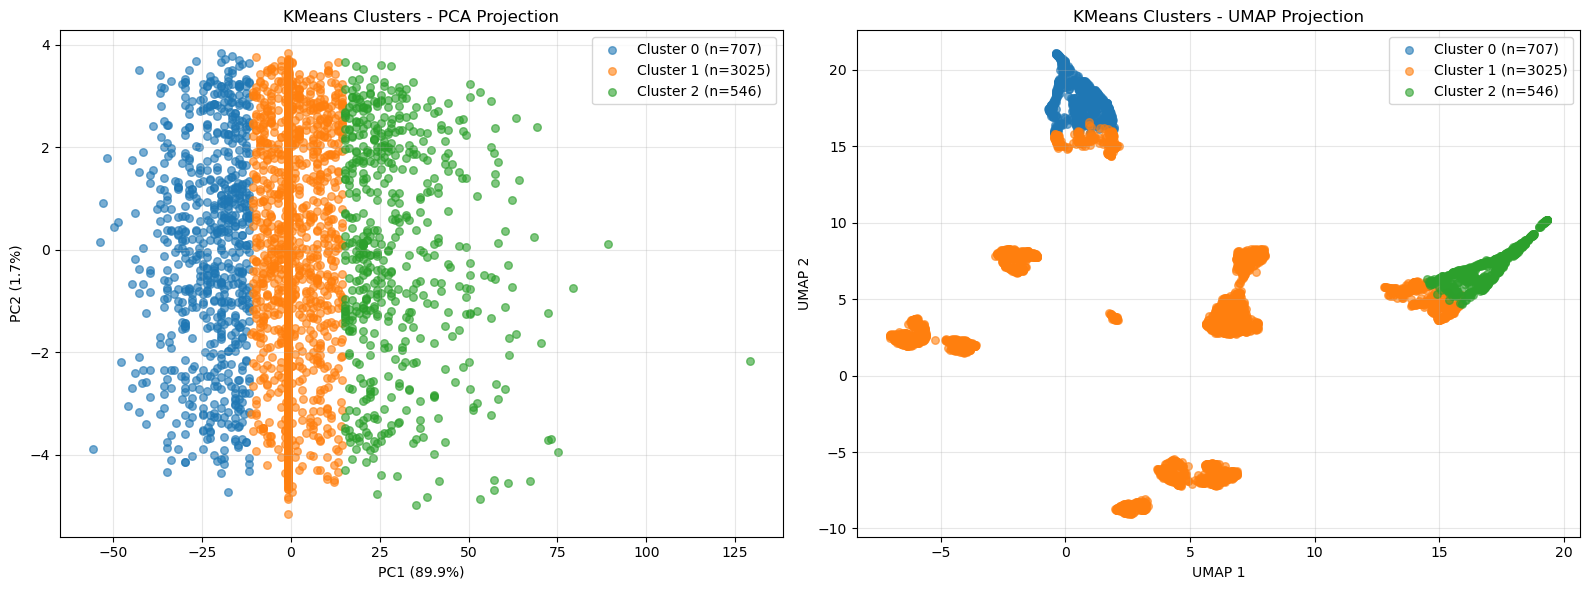

In [28]:
# Visualize clusters in PCA space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA visualization
for i in range(optimal_k):
    mask = kmeans_labels == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.6, s=30)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('KMeans Clusters - PCA Projection')
ax1.legend()
ax1.grid(True, alpha=0.3)

# UMAP visualization
for i in range(optimal_k):
    mask = kmeans_labels == i
    ax2.scatter(X_umap[mask, 0], X_umap[mask, 1],
               label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.6, s=30)

ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_title('KMeans Clusters - UMAP Projection')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Clinical Interpretation of Clusters

### Feature Comparison Across Clusters

In [14]:
# Helper function to create clinical summaries
def create_cluster_summary(df, cluster_col='kmeans_cluster', feature_groups=feature_groups):
    """
    Create detailed clinical summary for each cluster.
    """
    summaries = {}
    
    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster_id]
        n_patients = len(cluster_data)
        
        summary = {
            'n_patients': n_patients,
            'percentage': (n_patients / len(df)) * 100,
            'features': {}
        }
        
        # Compute statistics for each feature group
        for group_name, features in feature_groups.items():
            available_features = [f for f in features if f in df.columns]
            if available_features:
                group_stats = cluster_data[available_features].describe().loc[['mean', '50%', 'std']]
                summary['features'][group_name] = group_stats.T
        
        summaries[f'Cluster {cluster_id}'] = summary
    
    return summaries

# Create summaries
cluster_summaries = create_cluster_summary(df)

# Display summaries
for cluster_name, summary in cluster_summaries.items():
    print("="*80)
    print(f"{cluster_name}")
    print("="*80)
    print(f"Patients: {summary['n_patients']} ({summary['percentage']:.1f}%)")
    print("\n")
    
    for group_name, stats in summary['features'].items():
        print(f"\n{group_name}")
        print("-"*80)
        display(stats)
    print("\n")

Cluster 0
Patients: 3072 (71.8%)



Demographics
--------------------------------------------------------------------------------


,mean,50%,std
age,69.470551,69.82875,9.549642
gender,0.700195,1.00000,0.458247



Vital Signs
--------------------------------------------------------------------------------


,mean,50%,std
temperature,2.312779,2.309034,0.181779
heart_rate,4.346295,4.343805,0.134687
respiratory_rate,1.213550,1.212807,0.010434
oxygen_saturation,1.267295,1.386294,0.635372
bp_systolic,129.437826,129.000000,5.234091



Lab Values - Electrolytes
--------------------------------------------------------------------------------


...

,mean,50%,std
k_min,3.664885,3.6,0.404282
k_max,4.718626,4.6,0.538251



Healthcare Utilization
--------------------------------------------------------------------------------


,mean,50%,std
total_procedures,1.645268,1.732051,1.048500
total_tests,5.053271,5.111988,0.882972



Missingness Indicators
--------------------------------------------------------------------------------


,mean,50%,std
ct_complications_score_missing,0.618321,1.0,0.486170
infection_severity_score_missing,0.427481,0.0,0.495091


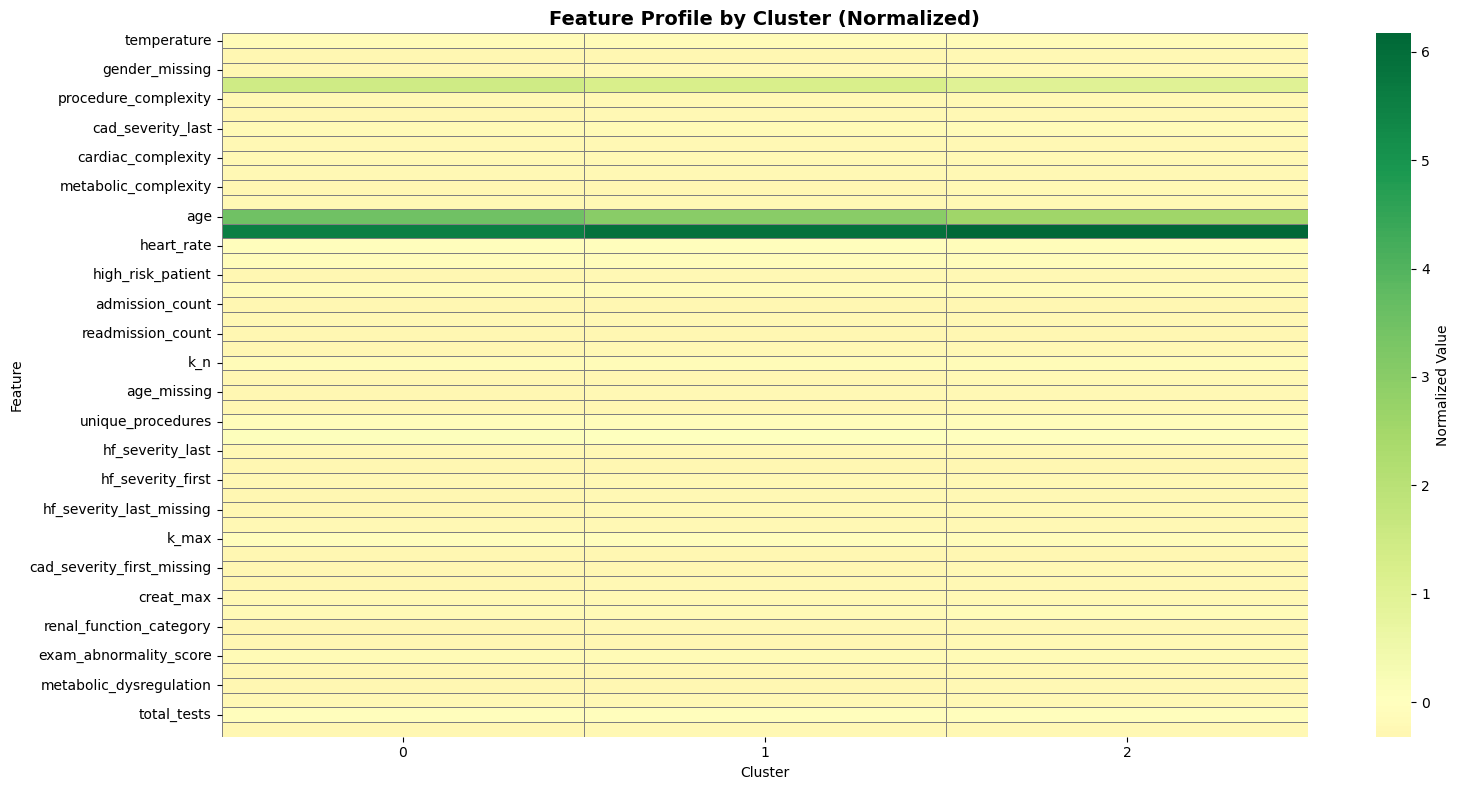

In [29]:
cluster_means = df.groupby('kmeans_cluster').mean()

# Normalize for better visualization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cluster_means_normalized = pd.DataFrame(
    scaler.fit_transform(cluster_means.T).T,
    columns=cluster_means.columns,
    index=cluster_means.index
)

plt.figure(figsize=(16, 8))
sns.heatmap(cluster_means_normalized.T, cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Normalized Value'}, 
            linewidths=0.5, linecolor='gray')
plt.title('Feature Profile by Cluster (Normalized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Statistical Testing: Feature Differences Between Clusters

In [30]:
# Kruskal-Wallis test for each feature
# (non-parametric test for differences across multiple groups)

kruskal_results = []

for feature in all_features:
    groups = [df[df['kmeans_cluster'] == i][feature].dropna() 
              for i in range(optimal_k)]
    
    # Only test if all groups have data
    if all(len(g) > 0 for g in groups):
        stat, p_value = kruskal(*groups)
        kruskal_results.append({
            'Feature': feature,
            'H-statistic': stat,
            'p-value': p_value,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })

kruskal_df = pd.DataFrame(kruskal_results).sort_values('p-value')

print("\nFeatures with Significant Differences Across Clusters (p < 0.05):")
print("="*80)
display(kruskal_df[kruskal_df['Significant'] == 'Yes'].head(15))

print(f"\nTotal significant features: {(kruskal_df['Significant'] == 'Yes').sum()}/{len(all_features)}")


Features with Significant Differences Across Clusters (p < 0.05):


,Feature,H-statistic,p-value,Significant
6,bp_systolic,3137.835678,0.000000e+00,Yes
3,heart_rate,46.227672,9.157744e-11,Yes
14,total_tests,44.812266,1.858404e-10,Yes
4,respiratory_rate,41.779847,8.464892e-10,Yes
2,temperature,35.293975,2.167758e-08,Yes
7,k_min,25.284014,3.233300e-06,Yes
21,infection_severity_score_missing,21.400755,2.253643e-05,Yes
8,k_max,19.720361,5.221292e-05,Yes
0,age,13.069334,1.452212e-03,Yes
18,gender_missing,10.320258,5.740958e-03,Yes



Total significant features: 14/22


### Box Plots: Key Clinical Features by Cluster

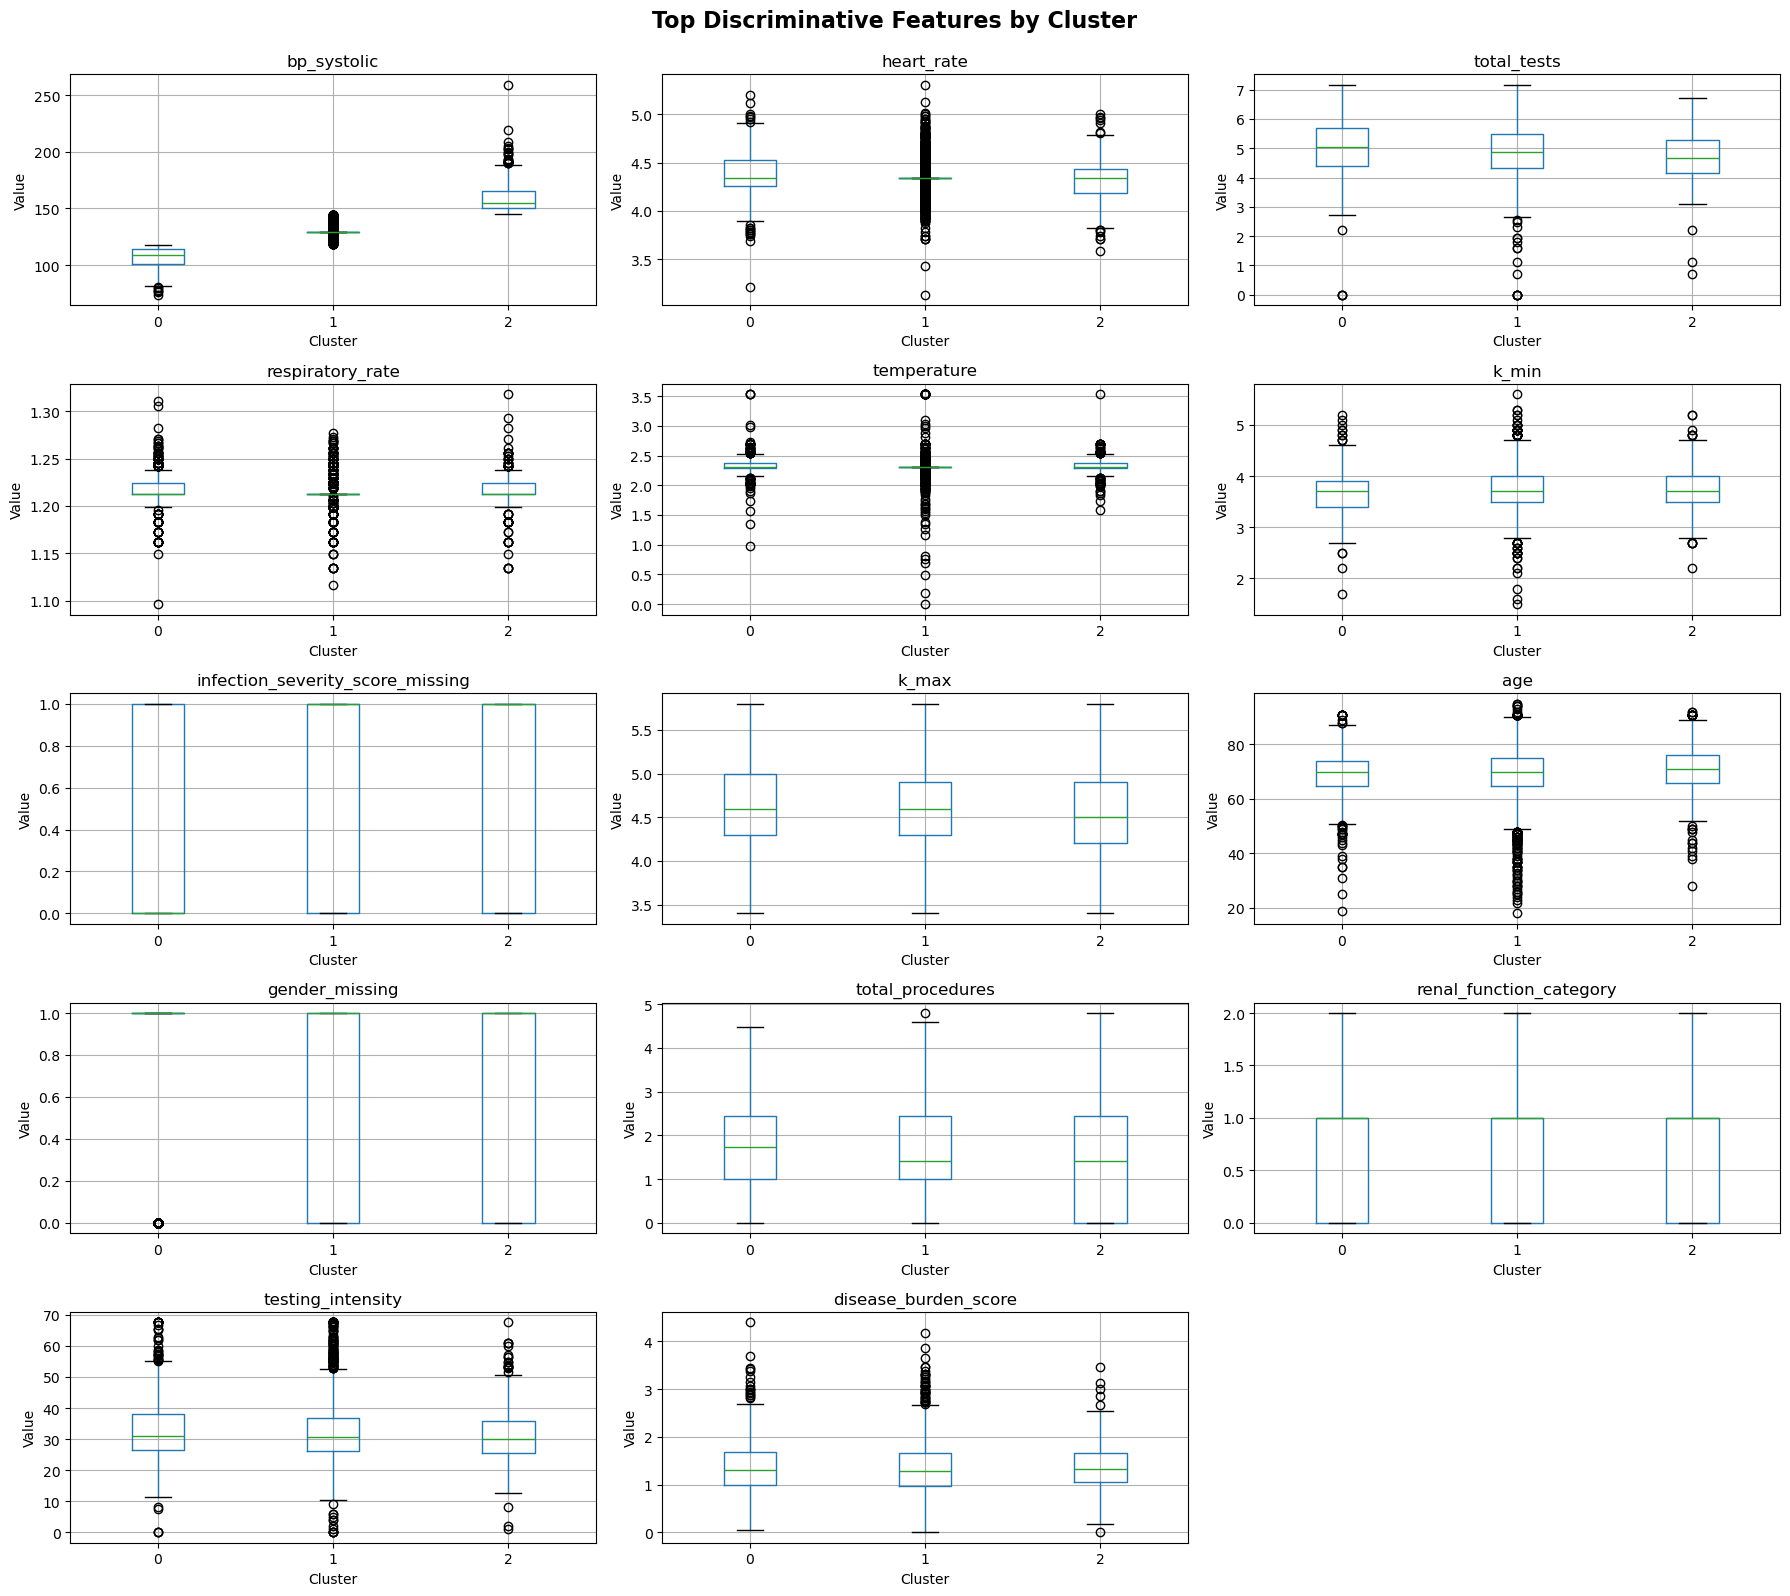

In [31]:
# Select most discriminative features for visualization
top_features = kruskal_df[kruskal_df['Significant'] == 'Yes']['Feature'].tolist()

top_features = [f for f in top_features if f in df.columns]

n_features = len(top_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 16))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    df.boxplot(column=feature, by='kmeans_cluster', ax=axes[idx])
    axes[idx].set_title(f'{feature}')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel('Value')
    plt.sca(axes[idx])
    plt.xticks(rotation=0)

for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('')
fig.suptitle('Top Discriminative Features by Cluster', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

We can redo clustering with significant features to see if we obtain a clean separation of the clusters.

In [32]:
X_significant = df[top_features]
X_sig_scaled = RobustScaler().fit_transform(X_significant)


In [33]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_sig_scaled)
    sil = silhouette_score(X_sig_scaled, labels)
    print(f"k={k}: Silhouette={sil:.3f}")

k=2: Silhouette=0.641
k=3: Silhouette=0.654
k=4: Silhouette=0.651
k=5: Silhouette=0.617
k=6: Silhouette=0.586


In [34]:
kmeans_sig = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
kmeans_labels_sig = kmeans.fit_predict(X_sig_scaled)

df['kmeans_cluster_sig'] = kmeans_labels_sig

In [35]:
X_pca_sig = pca.fit_transform(X_sig_scaled)
X_umap_sig = reducer.fit_transform(X_sig_scaled)

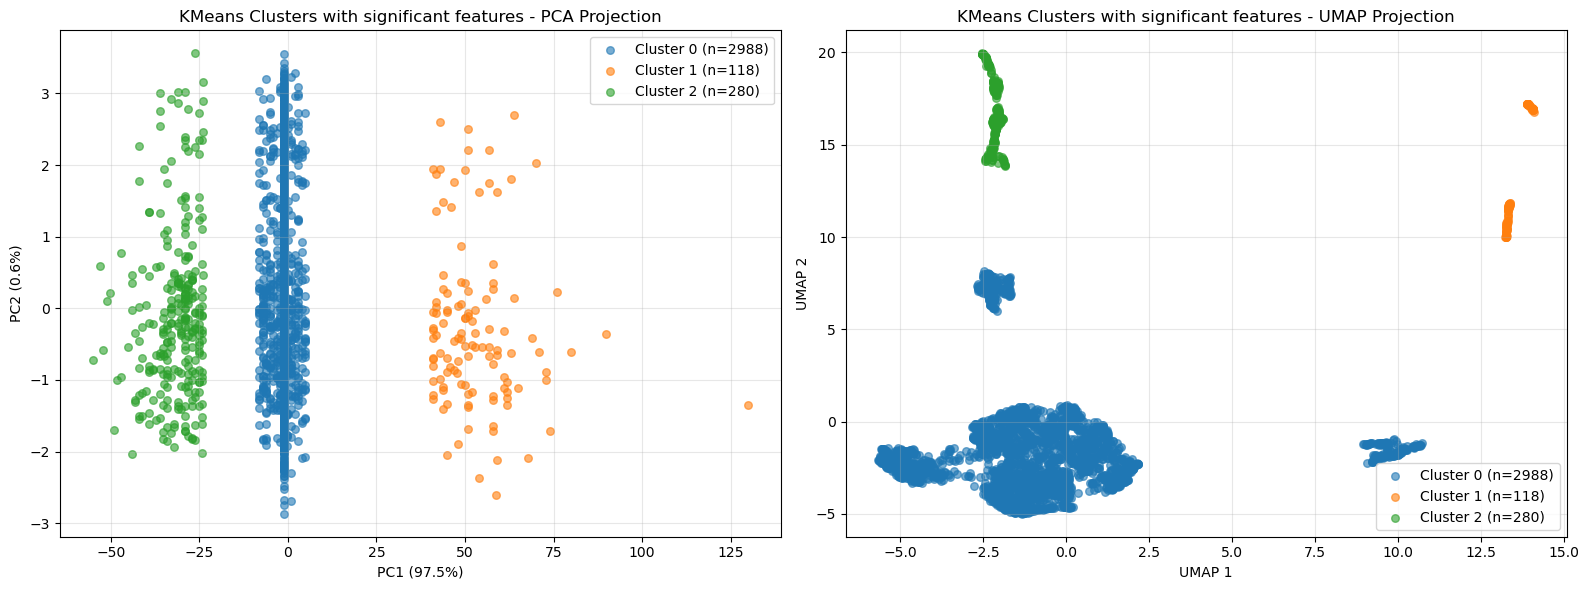

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA visualization
for i in range(optimal_k):
    mask = kmeans_labels_sig == i
    ax1.scatter(X_pca_sig[mask, 0], X_pca_sig[mask, 1], 
               label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.6, s=30)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('KMeans Clusters with significant features - PCA Projection')
ax1.legend()
ax1.grid(True, alpha=0.3)

# UMAP visualization
for i in range(optimal_k):
    mask = kmeans_labels_sig == i
    ax2.scatter(X_umap_sig[mask, 0], X_umap_sig[mask, 1],
               label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.6, s=30)

ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_title('KMeans Clusters with significant features - UMAP Projection')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Clinical interpretation of k-means clustering


**Cluster 1 (n=626) - Critically Ill Hypertensive Patients**

This cluster is clearly distinguished by:

- Systolic BP = 154 mmHg (highest among all clusters, severe hypertension)
- Age = 71.5 years (oldest)
- Lower Testing Intensity and Disease Burden despite age
- Lower Total Tests (9.9)

**Interpretation:** Elderly patients with severe hypertension but paradoxically with less clinical complexity. They may be hospitalized for management of primary hypertension or patients with stable chronic conditions.
​

**Cluster 0 (n=3404) - Standard/Normotensive Patients**
Characteristics:
- Systolic BP = 128 mmHg (normal values/prehypertension)
- Age = 70.3 years
- Total Tests = 11.0 (moderate)
- Disease Burden, Testing Intensity, and Procedure Complexity: Moderate
- Lower K Min and K Max

**Interpretation:** Main cluster with a standard profile, representing the majority of patients with routine medical conditions and normal vital signs.
​

**Cluster 2 (n=731) - Hypotensive/Highly Complex Patients**
Distinctive Profile:

- Systolic BP = 108 mmHg (lowest, relative hypotension)
- Testing Intensity and Disease Burden highest among all clusters
- Highest Total Tests (11.6)
- Highest Kmax (4.6) - possible electrolyte imbalance
- Age = 70.2 years (similar to others)

**Interpretation:** Critically ill patients with low blood pressure and maximum clinical complexity. They may be septic, in shock, or with multiple organ failure requiring intensive monitoring.

## Hierarchical Clustering

Computing hierarchical clustering on 1000 samples...


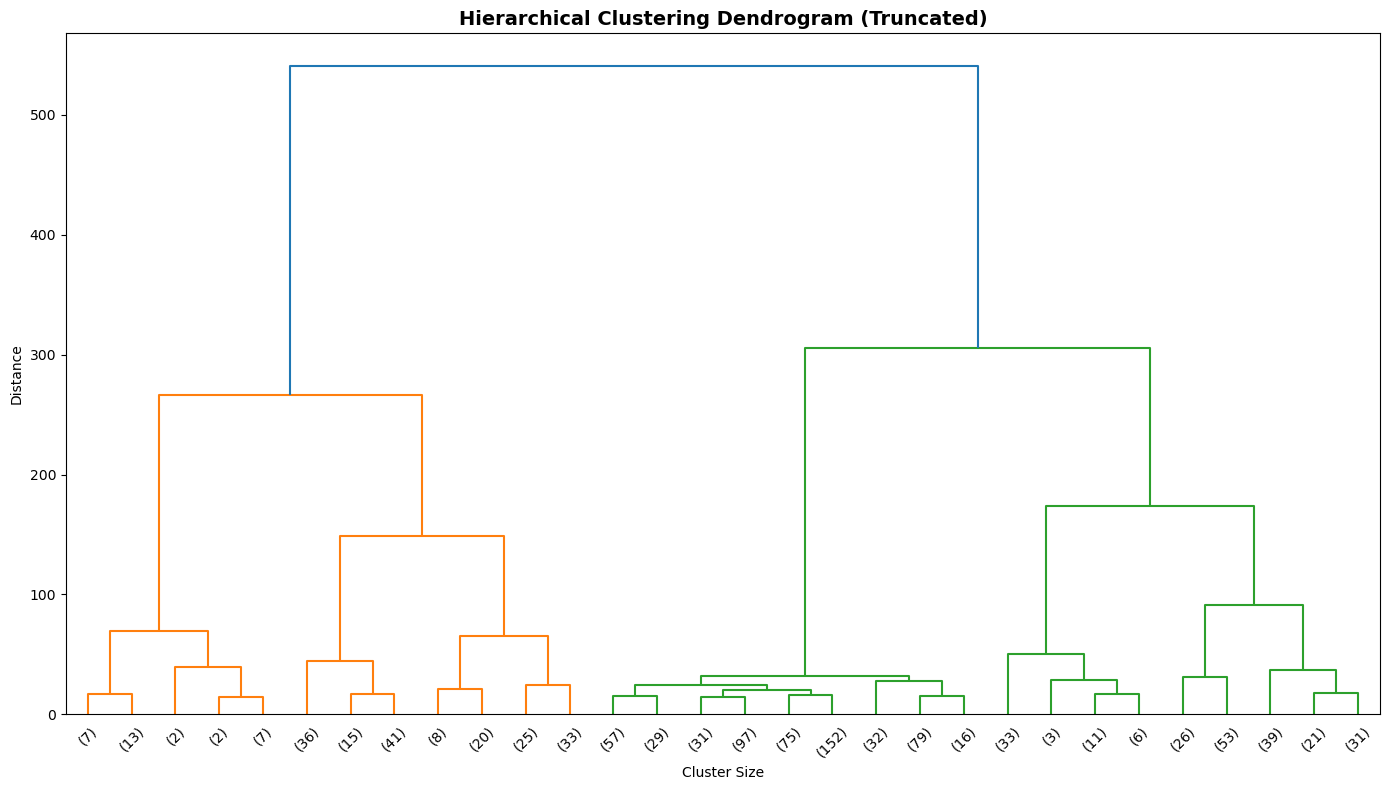

In [28]:
# Dendrogram for hierarchical clustering
# Use a sample for computational efficiency
sample_size = min(1000, len(df))
sample_indices = np.random.choice(len(X_sig_scaled), sample_size, replace=False)
X_sample = X_sig_scaled[sample_indices]

print(f"Computing hierarchical clustering on {sample_size} samples...")

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 8))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    show_leaf_counts=True,
    leaf_font_size=10
)
plt.title('Hierarchical Clustering Dendrogram (Truncated)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [29]:
# Perform hierarchical clustering on full dataset
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_sig_scaled)

df['hierarchical_cluster'] = hierarchical_labels

print(f"\nHierarchical Clustering Results:")
print(df['hierarchical_cluster'].value_counts().sort_index())

# Compare with KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(kmeans_labels_sig, hierarchical_labels)
nmi = normalized_mutual_info_score(kmeans_labels_sig, hierarchical_labels)

print(f"\nAgreement between KMeans and Hierarchical:")
print(f"  Adjusted Rand Index: {ari:.3f}")
print(f"  Normalized Mutual Information: {nmi:.3f}")


Hierarchical Clustering Results:
hierarchical_cluster
0     953
1     731
2    3077
Name: count, dtype: int64

Agreement between KMeans and Hierarchical:
  Adjusted Rand Index: 0.853
  Normalized Mutual Information: 0.765


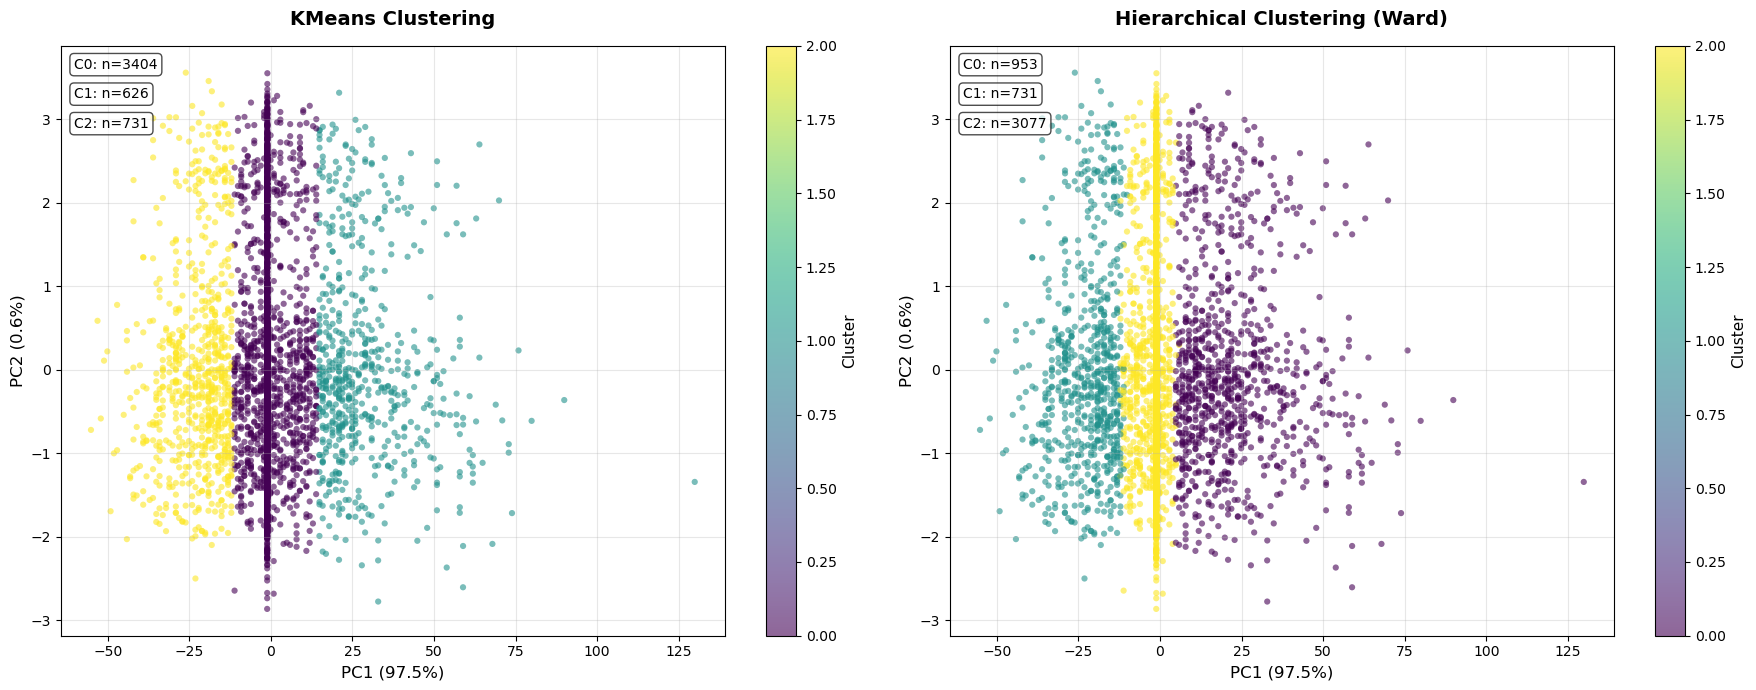

/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


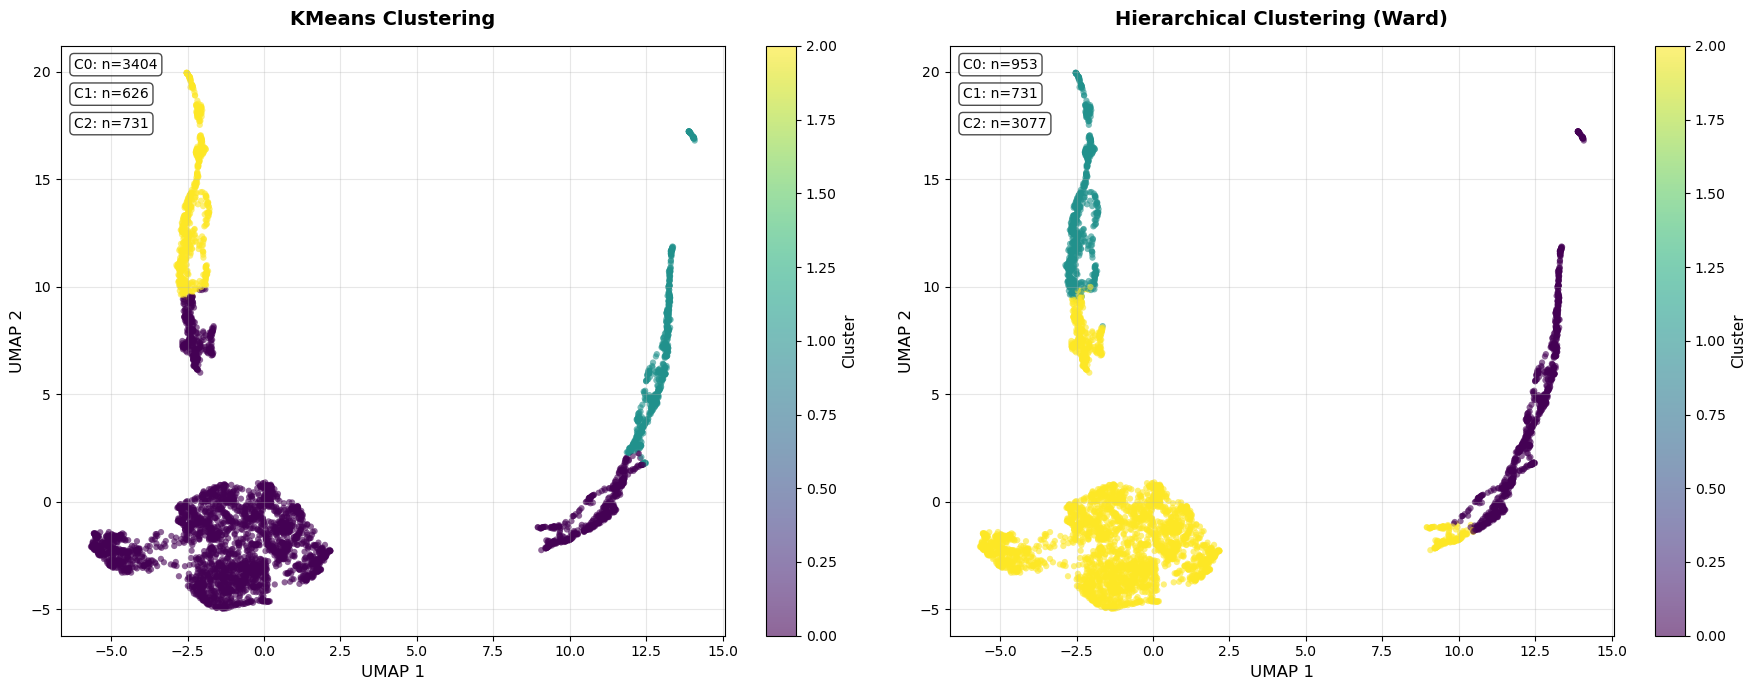

In [30]:
def plot_kmeans_vs_hierarchical(df, X_scaled, method='PCA'):
    """
    Compare KMeans and Hierarchical clustering side by side.
    """
    from sklearn.decomposition import PCA
    import umap
    
    # Dimensionality reduction
    if method == 'PCA':
        reducer = PCA(n_components=2, random_state=42)
        X_reduced = reducer.fit_transform(X_scaled)
        var_explained = reducer.explained_variance_ratio_
        xlabel = f'PC1 ({var_explained[0]*100:.1f}%)'
        ylabel = f'PC2 ({var_explained[1]*100:.1f}%)'
    else:  # UMAP
        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
        X_reduced = reducer.fit_transform(X_scaled)
        xlabel = 'UMAP 1'
        ylabel = 'UMAP 2'
    
    # Create side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # KMeans plot
    scatter1 = ax1.scatter(X_reduced[:, 0], X_reduced[:, 1], 
                          c=df['kmeans_cluster'], cmap='viridis', 
                          alpha=0.6, s=20, edgecolors='none')
    ax1.set_title('KMeans Clustering', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel(xlabel, fontsize=12)
    ax1.set_ylabel(ylabel, fontsize=12)
    cbar1 = plt.colorbar(scatter1, ax=ax1)
    cbar1.set_label('Cluster', fontsize=11)
    ax1.grid(alpha=0.3)
    
    # Add cluster counts
    for cluster_id in sorted(df['kmeans_cluster'].unique()):
        count = (df['kmeans_cluster'] == cluster_id).sum()
        ax1.text(0.02, 0.98 - cluster_id*0.05, f'C{cluster_id}: n={count}',
                transform=ax1.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Hierarchical plot
    scatter2 = ax2.scatter(X_reduced[:, 0], X_reduced[:, 1], 
                          c=df['hierarchical_cluster'], cmap='viridis', 
                          alpha=0.6, s=20, edgecolors='none')
    ax2.set_title('Hierarchical Clustering (Ward)', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel(xlabel, fontsize=12)
    ax2.set_ylabel(ylabel, fontsize=12)
    cbar2 = plt.colorbar(scatter2, ax=ax2)
    cbar2.set_label('Cluster', fontsize=11)
    ax2.grid(alpha=0.3)
    
    # Add cluster counts
    for cluster_id in sorted(df['hierarchical_cluster'].unique()):
        count = (df['hierarchical_cluster'] == cluster_id).sum()
        ax2.text(0.02, 0.98 - cluster_id*0.05, f'C{cluster_id}: n={count}',
                transform=ax2.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_kmeans_vs_hierarchical(df, X_sig_scaled, method='PCA')
plot_kmeans_vs_hierarchical(df, X_sig_scaled, method='UMAP')


## DBSCAN: Density-Based Clustering

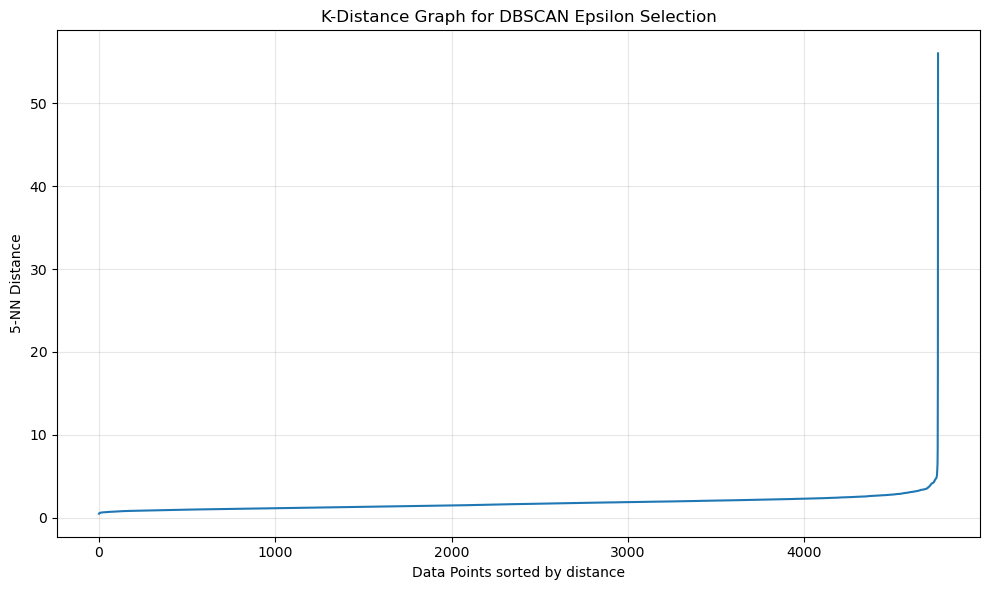


Suggested epsilon (90th percentile): 2.498


In [31]:
# DBSCAN parameter tuning
from sklearn.neighbors import NearestNeighbors

# K-distance graph to find optimal eps
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_sig_scaled)
distances, indices = nbrs.kneighbors(X_sig_scaled)

# Sort and plot
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.ylabel(f'{k}-NN Distance')
plt.xlabel('Data Points sorted by distance')
plt.title('K-Distance Graph for DBSCAN Epsilon Selection')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Suggest epsilon (look for "elbow" in the plot)
suggested_eps = np.percentile(distances, 90)
print(f"\nSuggested epsilon (90th percentile): {suggested_eps:.3f}")

In [32]:
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def dbscan_grid_search(X_scaled, eps_range, min_samples_range, 
                       max_noise_pct=15, min_silhouette=0.3):
    """
    Perform grid search for DBSCAN parameters.
    
    Parameters:
    -----------
    X_scaled : array-like
        Scaled feature matrix
    eps_range : list
        Range of eps values to test
    min_samples_range : list
        Range of min_samples values to test
    max_noise_pct : float
        Maximum acceptable percentage of noise points
    min_silhouette : float
        Minimum acceptable silhouette score
    
    Returns:
    --------
    best_params : dict
        Best parameters found
    results_df : DataFrame
        All results from grid search
    """
    results = []
    
    for eps in eps_range:
        for min_samples in min_samples_range:
            # Fit DBSCAN
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X_sig_scaled)
            
            # Calculate metrics
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_pct = (n_noise / len(labels)) * 100
            
            if n_clusters > 1 and n_noise < len(labels):
                mask = labels != -1
                if mask.sum() > 1:
                    try:
                        sil_score = silhouette_score(X_sig_scaled[mask], labels[mask])
                    except:
                        sil_score = -1
                else:
                    sil_score = -1
            else:
                sil_score = -1
            
            # Store results
            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_pct': noise_pct,
                'silhouette': sil_score
            })
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    # Filter valid results
    valid_results = results_df[
        (results_df['n_clusters'] >= 2) &  
        (results_df['noise_pct'] <= max_noise_pct) &  
        (results_df['silhouette'] >= min_silhouette)  
    ]
    
    if len(valid_results) == 0:
        valid_results = results_df[
            (results_df['n_clusters'] >= 2) &
            (results_df['noise_pct'] <= max_noise_pct * 1.5)
        ]
    
    if len(valid_results) > 0:
        
        valid_results['score'] = (
            -valid_results['noise_pct'] / 100 +  
            valid_results['silhouette']  
        )
        best_idx = valid_results['score'].idxmax()
        best_params = valid_results.loc[best_idx].to_dict()
        
    else:
        best_params = None
    
    return best_params, results_df


# Define parameter ranges
eps_range = np.arange(1.5, 3.5, 0.1)  
min_samples_range = range(5, 21, 2)  

# Run grid search
best_params, results_df = dbscan_grid_search(
    X_scaled, 
    eps_range, 
    min_samples_range,
    max_noise_pct=15,  
    min_silhouette=0.3  
)

# Extract best parameters
if best_params is not None:
    best_eps = best_params['eps']
    best_min_samples = int(best_params['min_samples'])
else:
    # Fallback to your original values
    best_eps = 2.208
    best_min_samples = 10

print(f"\nFinal parameters: eps={best_eps:.3f}, min_samples={best_min_samples}")


eps=1.500, min_samples= 5 | Clusters=15, Noise= 48.7%, Silhouette=0.364
eps=1.500, min_samples= 7 | Clusters=5, Noise= 51.5%, Silhouette=0.524
eps=1.500, min_samples= 9 | Clusters=1, Noise= 53.4%, Silhouette=-1.000
eps=1.500, min_samples=11 | Clusters=1, Noise= 54.0%, Silhouette=-1.000
eps=1.500, min_samples=13 | Clusters=1, Noise= 54.8%, Silhouette=-1.000
eps=1.500, min_samples=15 | Clusters=1, Noise= 55.6%, Silhouette=-1.000
eps=1.500, min_samples=17 | Clusters=1, Noise= 56.1%, Silhouette=-1.000
eps=1.500, min_samples=19 | Clusters=1, Noise= 56.9%, Silhouette=-1.000
eps=1.600, min_samples= 5 | Clusters=22, Noise= 42.8%, Silhouette=0.497
eps=1.600, min_samples= 7 | Clusters=13, Noise= 46.6%, Silhouette=-0.022
eps=1.600, min_samples= 9 | Clusters=7, Noise= 48.8%, Silhouette=0.353
eps=1.600, min_samples=11 | Clusters=2, Noise= 50.7%, Silhouette=0.801
eps=1.600, min_samples=13 | Clusters=1, Noise= 51.3%, Silhouette=-1.000
eps=1.600, min_samples=15 | Clusters=1, Noise= 52.1%, Silhouette=-

/tmp/ipykernel_20440/4122872007.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_results['score'] = (


In [34]:
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['dbscan_cluster'] = dbscan_labels

# Statistics
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nDBSCAN Results:")
print(f"  Number of clusters: {n_clusters}")
print(f"  Number of noise points: {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"\nCluster distribution:")
print(df['dbscan_cluster'].value_counts().sort_index())

# Calculate final silhouette
if n_clusters > 1 and n_noise < len(df):
    mask = dbscan_labels != -1
    if mask.sum() > 1:
        final_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        print(f"\nFinal Silhouette Score: {final_sil:.3f}")



DBSCAN Results:
  Number of clusters: 7
  Number of noise points: 1918 (40.3%)

Cluster distribution:
dbscan_cluster
-1    1918
 0    2676
 1      63
 2      19
 3      33
 4      17
 5      18
 6      17
Name: count, dtype: int64

Final Silhouette Score: 0.463


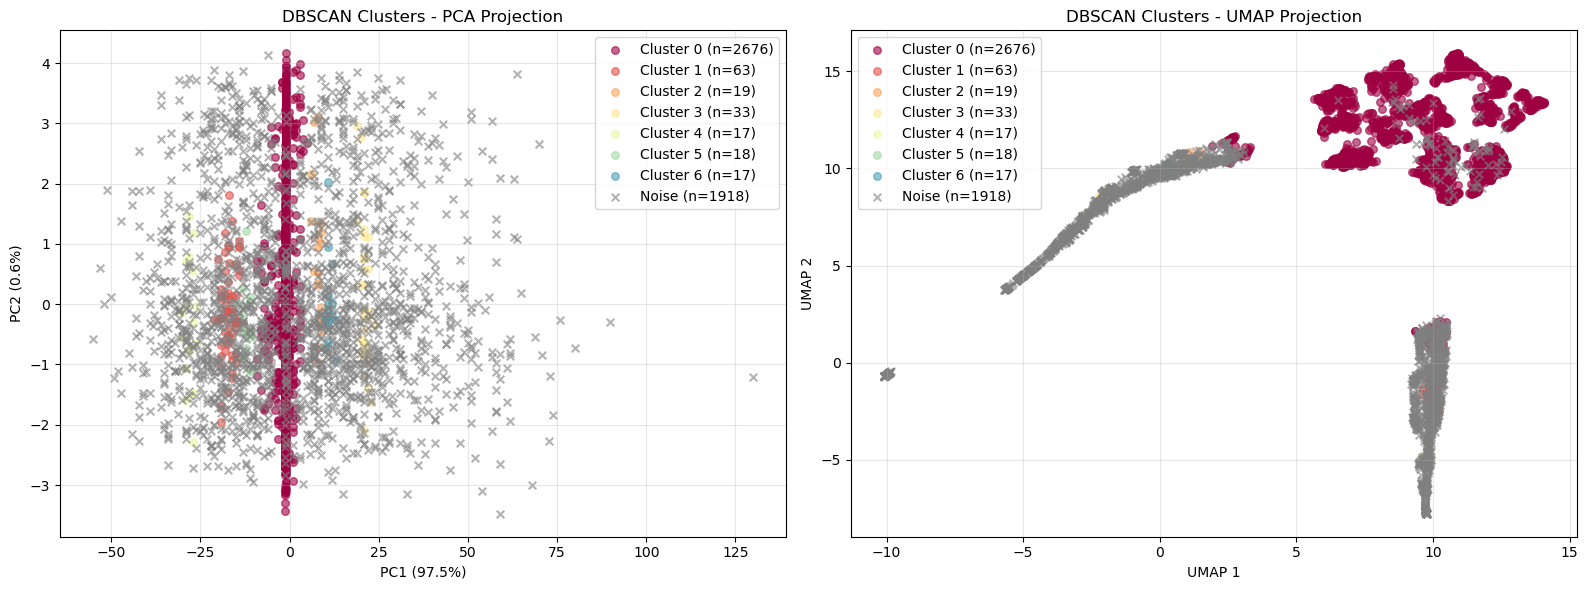

In [35]:
# Visualize DBSCAN clusters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA
unique_labels = set(dbscan_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        color = 'gray'
        marker = 'x'
        label_str = 'Noise'
    else:
        marker = 'o'
        label_str = f'Cluster {label}'
    
    mask = dbscan_labels == label
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[color], marker=marker, label=f'{label_str} (n={mask.sum()})',
               alpha=0.6, s=30)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('DBSCAN Clusters - PCA Projection')
ax1.legend()
ax1.grid(True, alpha=0.3)

# UMAP
for label, color in zip(unique_labels, colors):
    if label == -1:
        color = 'gray'
        marker = 'x'
        label_str = 'Noise'
    else:
        marker = 'o'
        label_str = f'Cluster {label}'
    
    mask = dbscan_labels == label
    ax2.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=[color], marker=marker, label=f'{label_str} (n={mask.sum()})',
               alpha=0.6, s=30)

ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_title('DBSCAN Clusters - UMAP Projection')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Comparison & Final Selection

In [36]:
# Compare all clustering methods
comparison = pd.DataFrame({
    'Method': ['KMeans', 'Hierarchical', 'DBSCAN'],
    'N_Clusters': [
        len(df['kmeans_cluster_sig'].unique()),
        len(df['hierarchical_cluster'].unique()),
        len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    ],
    'Silhouette': [
        silhouette_score(X_sig_scaled, kmeans_labels),
        silhouette_score(X_sig_scaled, hierarchical_labels),
        silhouette_score(X_sig_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else np.nan
    ],
    'Davies-Bouldin': [
        davies_bouldin_score(X_sig_scaled, kmeans_labels),
        davies_bouldin_score(X_sig_scaled, hierarchical_labels),
        davies_bouldin_score(X_sig_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else np.nan
    ],
    'Calinski-Harabasz': [
        calinski_harabasz_score(X_sig_scaled, kmeans_labels),
        calinski_harabasz_score(X_sig_scaled, hierarchical_labels),
        calinski_harabasz_score(X_sig_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else np.nan
    ]
})

print("Clustering Method Comparison")
print("="*80)
display(comparison)

print("\n💡 Interpretation:")
print("  - Silhouette Score: Higher is better (>0.5 is good)")
print("  - Davies-Bouldin: Lower is better")
print("  - Calinski-Harabasz: Higher is better")

Clustering Method Comparison


,Method,N_Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,6,0.658511,0.501466,8652.335496
1,Hierarchical,3,0.626379,0.571022,6783.850445
2,DBSCAN,7,0.053478,3.091572,38.614158



💡 Interpretation:
  - Silhouette Score: Higher is better (>0.5 is good)
  - Davies-Bouldin: Lower is better
  - Calinski-Harabasz: Higher is better


KMEANS is the best method for clustering the patients, based on metrics and visual separation of the clusters